# ***Supply Chain Network Optimization***


**Business Problem**

This project optimizes the distribution network for a premium automotive component manufacturer supplying parts to major OEM (vehicle manufacturer) clusters across India.

The network:

1.   2 manufacturing plants — Pune and Chennai — with a combined production capacity of 1,000 units/day

2.   4 candidate distribution centers (DCs) — Delhi, Mumbai, Bengaluru, and Kolkata — each with a different fixed monthly operating cost and maximum daily throughput capacity

3. 5 customer clusters — major OEM manufacturing hubs (Gurgaon, Chennai, Pune, Ahmedabad, and Jamshedpur) — each with a fixed daily demand that must be met


The goal: determine which distribution centers to open (and which to keep closed), and how many units to ship along each route (plant → DC → customer), in order to meet all customer demand at the lowest possible total daily cost — combining DC fixed operating costs and per-unit shipping costs across the network.




**Section 2: Data Sources & Assumptions**

The dataset for this project was constructed using a combination of real, published cost benchmarks and clearly documented assumptions where granular public data wasn't available, a common and standard practice in supply chain analytics when building illustrative or academic models.


**Real sourced benchmarks:**


1.   Road freight cost: India's average road freight cost of ₹3.78 per tonne-km(2025 industry logistics data) was used as the base rate for all shipping cost calculations.

2.   Warehouse/industrial rent: Monthly rent per square foot for Delhi-NCR, Mumbai, Bengaluru, and Kolkata was based on 2025 industrial real estate data (Vestian), reflecting current market rates by geography.

**Shipping cost formula:**

Cost per unit (₹) = Distance (km) × Assumed unit weight (tons) × ₹3.78/tonne-km

**Assumptions made explicitly (and why):**
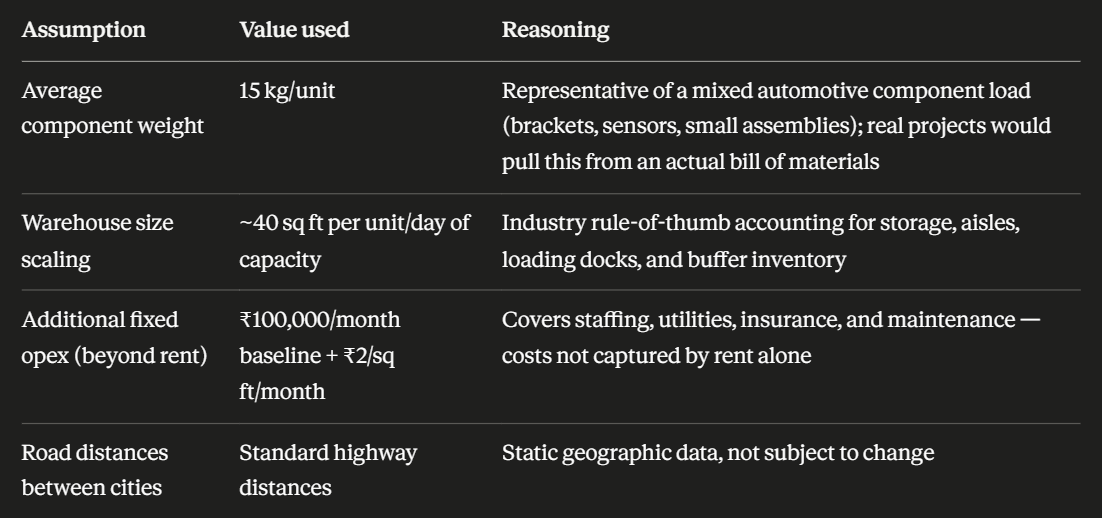



# **Reference Data Tables**

| Plant | Capacity (units/day) |
|---|---|
| Pune | 600 |
| Chennai | 400 |

 **Distribution Centers (candidates):**
 | DC | Fixed Monthly Cost (₹) | Capacity (units/day) |
|---|---|---|
| Delhi | 468,000 | 400 |
| Mumbai | 460,000 | 450 |
| Bengaluru | 394,000 | 350 |
| Kolkata | 376,000 | 300 |

**Customers**
| Customer | Demand (units/day) |
|---|---|
| Gurgaon | 250 |
| Chennai | 200 |
| Pune | 180 |
| Ahmedabad | 170 |
| Jamshedpur | 200 |

**Shipping cost — Plant → DC (₹/unit)**

| | Delhi | Mumbai | Bengaluru | Kolkata |
|---|---|---|---|---|
| Pune | 87 | 9 | 50 | 114 |
| Chennai | 131 | 80 | 21 | 100 |

**Shipping cost — DC → Customer (₹/unit):**
| | Gurgaon | Chennai | Pune | Ahmedabad | Jamshedpur |
|---|---|---|---|---|---|
| Delhi | 2 | 131 | 87 | 57 | 78 |
| Mumbai | 86 | 80 | 9 | 32 | 114 |
| Bengaluru | 129 | 21 | 50 | 90 | 111 |
| Kolkata | 90 | 100 | 114 | 117 | 24 |



In [ ]:
# Plants
plants = ["Pune", "Chennai"]
plant_capacity = {"Pune": 600, "Chennai": 400}

# Distribution Centers
dcs = ["Delhi", "Mumbai", "Bengaluru", "Kolkata"]
dc_capacity = {"Delhi": 400, "Mumbai": 450, "Bengaluru": 350, "Kolkata": 300}
dc_fixed_cost = {"Delhi": 468000, "Mumbai": 460000, "Bengaluru": 394000, "Kolkata": 376000}

# Customers
customers = ["Gurgaon", "Chennai", "Pune", "Ahmedabad", "Jamshedpur"]
customer_demand = {"Gurgaon": 250, "Chennai": 200, "Pune": 180, "Ahmedabad": 170, "Jamshedpur": 200}

# Shipping costs: Plant -> DC
plant_dc_cost = {
    "Pune": {"Delhi": 87, "Mumbai": 9, "Bengaluru": 50, "Kolkata": 114},
    "Chennai": {"Delhi": 131, "Mumbai": 80, "Bengaluru": 21, "Kolkata": 100}
}

# Shipping costs: DC -> Customer
dc_customer_cost = {
    "Delhi": {"Gurgaon": 2, "Chennai": 131, "Pune": 87, "Ahmedabad": 57, "Jamshedpur": 78},
    "Mumbai": {"Gurgaon": 86, "Chennai": 80, "Pune": 9, "Ahmedabad": 32, "Jamshedpur": 114},
    "Bengaluru": {"Gurgaon": 129, "Chennai": 21, "Pune": 50, "Ahmedabad": 90, "Jamshedpur": 111},
    "Kolkata": {"Gurgaon": 90, "Chennai": 100, "Pune": 114, "Ahmedabad": 117, "Jamshedpur": 24}
}

print("All data loaded successfully")

All data loaded successfully


In [ ]:
!pip install pulp
import pulp

**Section 3: Decision Variables**

Three sets of decision variables represent the choices the model is free to determine:

1.   ship_plant_dc — continuous variables for units shipped from each plant to each DC
2.   ship_dc_customer — continuous variables for units shipped from each DC to each customer
3. open_dc — binary variables indicating whether each DC is opened (1) or kept closed (0)





In [ ]:
# Plant -> DC shipment quantities (continuous)
ship_plant_dc = {}
for plant in plants:
    ship_plant_dc[plant] = {}
    for dc in dcs:
        var_name = f"ship_{plant}_{dc}"
        ship_plant_dc[plant][dc] = pulp.LpVariable(var_name, lowBound=0)

print(ship_plant_dc)

{'Pune': {'Delhi': ship_Pune_Delhi, 'Mumbai': ship_Pune_Mumbai, 'Bengaluru': ship_Pune_Bengaluru, 'Kolkata': ship_Pune_Kolkata}, 'Chennai': {'Delhi': ship_Chennai_Delhi, 'Mumbai': ship_Chennai_Mumbai, 'Bengaluru': ship_Chennai_Bengaluru, 'Kolkata': ship_Chennai_Kolkata}}


In [ ]:
# DC -> Customer shipment quantities (continuous)
ship_dc_customer = {}
for dc in dcs:
  ship_dc_customer[dc] = {}
  for customer in customers:
    var_name = f"ship_{dc}_{customer}"
    ship_dc_customer[dc][customer] = pulp.LpVariable(var_name,lowBound=0)

print(ship_dc_customer)

{'Delhi': {'Gurgaon': ship_Delhi_Gurgaon, 'Chennai': ship_Delhi_Chennai, 'Pune': ship_Delhi_Pune, 'Ahmedabad': ship_Delhi_Ahmedabad, 'Jamshedpur': ship_Delhi_Jamshedpur}, 'Mumbai': {'Gurgaon': ship_Mumbai_Gurgaon, 'Chennai': ship_Mumbai_Chennai, 'Pune': ship_Mumbai_Pune, 'Ahmedabad': ship_Mumbai_Ahmedabad, 'Jamshedpur': ship_Mumbai_Jamshedpur}, 'Bengaluru': {'Gurgaon': ship_Bengaluru_Gurgaon, 'Chennai': ship_Bengaluru_Chennai, 'Pune': ship_Bengaluru_Pune, 'Ahmedabad': ship_Bengaluru_Ahmedabad, 'Jamshedpur': ship_Bengaluru_Jamshedpur}, 'Kolkata': {'Gurgaon': ship_Kolkata_Gurgaon, 'Chennai': ship_Kolkata_Chennai, 'Pune': ship_Kolkata_Pune, 'Ahmedabad': ship_Kolkata_Ahmedabad, 'Jamshedpur': ship_Kolkata_Jamshedpur}}


In [ ]:
# Whether each DC is opened (binary: 1 = open, 0 = closed)
open_dc = {}
for dc in dcs:
    var_name = f"open_{dc}"
    open_dc[dc] = pulp.LpVariable(var_name, cat="Binary")

print(open_dc)

{'Delhi': open_Delhi, 'Mumbai': open_Mumbai, 'Bengaluru': open_Bengaluru, 'Kolkata': open_Kolkata}


In [ ]:
open_dc = {}
for dc in dcs:
    var_name = f"open_{dc}"
    open_dc[dc] = pulp.LpVariable(var_name, cat="Binary")

print(open_dc)

{'Delhi': open_Delhi, 'Mumbai': open_Mumbai, 'Bengaluru': open_Bengaluru, 'Kolkata': open_Kolkata}


**Section 4: Objective Function & Constraints**

The objective minimizes total daily cost.The sum of DC fixed costs (only incurred if opened), Plant→DC shipping costs, and DC→Customer shipping costs. Four constraints enforce the business rules:

1.   plant output cannot exceed capacity
2.   customer demand must be fully met
3. DC throughput cannot exceed capacity
4.  units flowing into each DC must equal units flowing out.



In [ ]:
# Objective: minimize total cost = DC fixed costs + Plant->DC shipping + DC->Customer shipping
model = pulp.LpProblem("Supply_Chain_Optimization", pulp.LpMinimize)

fixed_costs = pulp.lpSum([dc_fixed_cost[dc] * open_dc[dc] for dc in dcs])

plant_dc_costs = pulp.lpSum([plant_dc_cost[plant][dc] * ship_plant_dc[plant][dc]
                             for plant in plants for dc in dcs])

dc_customer_costs = pulp.lpSum([dc_customer_cost[dc][customer] * ship_dc_customer[dc][customer]
                                for dc in dcs for customer in customers])

model += fixed_costs + plant_dc_costs + dc_customer_costs, "Total_Cost"

In [ ]:
for plant in plants:
    model += pulp.lpSum([ship_plant_dc[plant][dc] for dc in dcs]) <= plant_capacity[plant]
for customer in customers:
  model += pulp.lpSum([ship_dc_customer[dc][customer] for dc in dcs]) == customer_demand[customer]
for dc in dcs:
  model += pulp.lpSum([ship_dc_customer[dc][customer] for customer in customers]) <= dc_capacity[dc] * open_dc[dc]
  for dc in dcs:
    model += pulp.lpSum([ship_plant_dc[plant][dc] for plant in plants]) == pulp.lpSum([ship_dc_customer[dc][customer] for customer in customers])

In [ ]:
for plant in plants:
    model += pulp.lpSum([ship_plant_dc[plant][dc] for dc in dcs]) <= plant_capacity[plant]
for customer in customers:
  model += pulp.lpSum([ship_dc_customer[dc][customer] for dc in dcs]) == customer_demand[customer]
for dc in dcs:
  model += pulp.lpSum([ship_dc_customer[dc][customer] for customer in customers]) <= dc_capacity[dc] * open_dc[dc]
  for dc in dcs:
    model += pulp.lpSum([ship_plant_dc[plant][dc] for plant in plants]) == pulp.lpSum([ship_dc_customer[dc][customer] for customer in customers])

In [ ]:
# Solve the model and display the optimal total cost
model.solve()
print("Status:", pulp.LpStatus[model.status])
print("Total Cost: ₹", pulp.value(model.objective))


Status: Optimal
Total Cost: ₹ 1307210.0


**Section 5: Base Results**

The optimized network recommends opening Mumbai, Bengaluru, and Kolkata, while keeping Delhi closed, meeting all customer demand at a minimum total daily cost of ₹13,07,210. Full route-level shipment quantities are shown below.

In [ ]:
# Extract and display the optimal solution: which DCs are open, and shipment quantities on each route
print("Which DCs are open:")
for dc in dcs:
    status = "OPEN" if open_dc[dc].varValue == 1 else "closed"
    print(f"  {dc}: {status}")

print("\nPlant → DC shipments:")
for plant in plants:
    for dc in dcs:
        qty = ship_plant_dc[plant][dc].varValue
        if qty > 0:
            print(f"  {plant} → {dc}: {qty} units")

print("\nDC → Customer shipments:")
for dc in dcs:
    for customer in customers:
        qty = ship_dc_customer[dc][customer].varValue
        if qty > 0:
            print(f"  {dc} → {customer}: {qty} units")

Which DCs are open:
  Delhi: closed
  Mumbai: OPEN
  Bengaluru: OPEN
  Kolkata: OPEN

Plant → DC shipments:
  Pune → Mumbai: 450.0 units
  Pune → Kolkata: 150.0 units
  Chennai → Bengaluru: 350.0 units
  Chennai → Kolkata: 50.0 units

DC → Customer shipments:
  Mumbai → Gurgaon: 250.0 units
  Mumbai → Pune: 30.0 units
  Mumbai → Ahmedabad: 170.0 units
  Bengaluru → Chennai: 200.0 units
  Bengaluru → Pune: 150.0 units
  Kolkata → Jamshedpur: 200.0 units


 ***Insight***

 Despite Delhi→Gurgaon being the single cheapest route in the entire network (₹2/unit), the model still keeps Delhi closed. The ₹4,68,000/month fixed cost of opening it outweighs the shipping savings from that one route. This illustrates the core trade-off in facility location decisions: fixed costs vs. variable shipping costs.

# **Section 6: Sensitivity Analysis — Freight Cost Increase**

To test the network's resilience, all shipping costs were increased by 15% (simulating a fuel price shock), and the model was re-solved to see whether the optimal facility footprint changes.

In [ ]:
# Scale all shipping costs up by 15% to simulate a freight cost increase
plant_dc_cost_high = {}
for plant in plants:
    plant_dc_cost_high[plant] = {}
    for dc in dcs:
        plant_dc_cost_high[plant][dc] = plant_dc_cost[plant][dc] * 1.15

dc_customer_cost_high = {}
for dc in dcs:
    dc_customer_cost_high[dc] = {}
    for customer in customers:
        dc_customer_cost_high[dc][customer] = dc_customer_cost[dc][customer] * 1.15

print(plant_dc_cost_high)
print(dc_customer_cost_high)

{'Pune': {'Delhi': 100.05, 'Mumbai': 10.35, 'Bengaluru': 57.49999999999999, 'Kolkata': 131.1}, 'Chennai': {'Delhi': 150.64999999999998, 'Mumbai': 92.0, 'Bengaluru': 24.15, 'Kolkata': 114.99999999999999}}
{'Delhi': {'Gurgaon': 2.3, 'Chennai': 150.64999999999998, 'Pune': 100.05, 'Ahmedabad': 65.55, 'Jamshedpur': 89.69999999999999}, 'Mumbai': {'Gurgaon': 98.89999999999999, 'Chennai': 92.0, 'Pune': 10.35, 'Ahmedabad': 36.8, 'Jamshedpur': 131.1}, 'Bengaluru': {'Gurgaon': 148.35, 'Chennai': 24.15, 'Pune': 57.49999999999999, 'Ahmedabad': 103.49999999999999, 'Jamshedpur': 127.64999999999999}, 'Kolkata': {'Gurgaon': 103.49999999999999, 'Chennai': 114.99999999999999, 'Pune': 131.1, 'Ahmedabad': 134.54999999999998, 'Jamshedpur': 27.599999999999998}}


In [ ]:
model_high = pulp.LpProblem("Supply_Chain_High_Freight", pulp.LpMinimize)

fixed_costs_h = pulp.lpSum([dc_fixed_cost[dc] * open_dc[dc] for dc in dcs])
plant_dc_costs_h = pulp.lpSum([plant_dc_cost_high[plant][dc] * ship_plant_dc[plant][dc]
                               for plant in plants for dc in dcs])
dc_customer_costs_h = pulp.lpSum([dc_customer_cost_high[dc][customer] * ship_dc_customer[dc][customer]
                                  for dc in dcs for customer in customers])

model_high += fixed_costs_h + plant_dc_costs_h + dc_customer_costs_h, "Total_Cost_High_Freight"

# Re-add all the same constraints, but attached to model_high this time
for plant in plants:
    model_high += pulp.lpSum([ship_plant_dc[plant][dc] for dc in dcs]) <= plant_capacity[plant]

for customer in customers:
    model_high += pulp.lpSum([ship_dc_customer[dc][customer] for dc in dcs]) == customer_demand[customer]

for dc in dcs:
    model_high += pulp.lpSum([ship_dc_customer[dc][customer] for customer in customers]) <= dc_capacity[dc] * open_dc[dc]

for dc in dcs:
    model_high += pulp.lpSum([ship_plant_dc[plant][dc] for plant in plants]) == pulp.lpSum([ship_dc_customer[dc][customer] for customer in customers])

model_high.solve()
print("Status:", pulp.LpStatus[model_high.status])
print("Total Cost (High Freight): ₹", pulp.value(model_high.objective))

Status: Optimal
Total Cost (High Freight): ₹ 1318791.5


In [ ]:
# Check whether the optimal DC selection changed under high freight costs
print("Which DCs are open (High Freight scenario):")
for dc in dcs:
    status = "OPEN" if open_dc[dc].varValue == 1 else "closed"
    print(f"  {dc}: {status}")


Which DCs are open (High Freight scenario):
  Delhi: closed
  Mumbai: OPEN
  Bengaluru: OPEN
  Kolkata: OPEN


# Insight:

A uniform 15% increase in freight costs raised the total cost proportionally (₹13,07,210 → ₹13,18,791.5) but did not change which DCs were opened (Mumbai, Bengaluru, Kolkata remained open; Delhi remained closed). This shows the network's facility footprint is structurally robust to uniform cost inflation — scaling every route by the same factor preserves each route's relative ranking, so the optimizer's decisions don't change, only the total spend does. A more disruptive scenario would be an asymmetric cost shock affecting only specific routes or regions.

**Extension : Direct Plant to Customer Shipping**

In [ ]:
# Direct shipping cost: Plant -> Customer (bypassing DCs entirely)
plant_customer_cost = {"Pune": {"Gurgaon": 80, "Chennai": 67, "Pune": 5, "Ahmedabad": 37, "Jamshedpur": 96},
    "Chennai": {"Gurgaon": 125, "Chennai": 5, "Pune": 67, "Ahmedabad": 94, "Jamshedpur": 94}}




In [ ]:
# Direct Plant -> Customer shipment quantities (continuous)
ship_plant_customer = {}
for plant in plants:
      ship_plant_customer[plant] = {}
      for customer in customers:
        var_name = f"direct_{plant}_{customer}"
        ship_plant_customer[plant][customer] = pulp.LpVariable(var_name, lowBound=0)


print(ship_plant_customer)

{'Pune': {'Gurgaon': direct_Pune_Gurgaon, 'Chennai': direct_Pune_Chennai, 'Pune': direct_Pune_Pune, 'Ahmedabad': direct_Pune_Ahmedabad, 'Jamshedpur': direct_Pune_Jamshedpur}, 'Chennai': {'Gurgaon': direct_Chennai_Gurgaon, 'Chennai': direct_Chennai_Chennai, 'Pune': direct_Chennai_Pune, 'Ahmedabad': direct_Chennai_Ahmedabad, 'Jamshedpur': direct_Chennai_Jamshedpur}}


In [ ]:
# Objective for direct-shipping model: adds direct plant->customer cost as a 4th term
model_direct = pulp.LpProblem("Supply_Chain_With_Direct_Shipping", pulp.LpMinimize)

fixed_costs_d = pulp.lpSum([dc_fixed_cost[dc] * open_dc[dc] for dc in dcs])
plant_dc_costs_d = pulp.lpSum([plant_dc_cost[plant][dc] * ship_plant_dc[plant][dc]
                               for plant in plants for dc in dcs])
dc_customer_costs_d = pulp.lpSum([dc_customer_cost[dc][customer] * ship_dc_customer[dc][customer]
                                  for dc in dcs for customer in customers])
direct_costs_d = pulp.lpSum([plant_customer_cost[plant][customer] * ship_plant_customer[plant][customer]
                             for plant in plants for customer in customers])

model_direct += fixed_costs_d + plant_dc_costs_d + dc_customer_costs_d + direct_costs_d, "Total_Cost_Direct"

In [ ]:
# Constraint: plant capacity now covers BOTH DC-bound and direct shipments combined
for plant in plants:
    model_direct += (pulp.lpSum([ship_plant_dc[plant][dc] for dc in dcs]) +
                      pulp.lpSum([ship_plant_customer[plant][customer] for customer in customers])
                      ) <= plant_capacity[plant]

In [ ]:
# Constraint: customer demand can now be met by DC shipments OR direct shipments (or both)
for customer in customers:
    model_direct += (pulp.lpSum([ship_dc_customer[dc][customer] for dc in dcs]) +
                      pulp.lpSum([ship_plant_customer[plant][customer] for plant in plants])
                      ) == customer_demand[customer]

In [ ]:
# DC capacity and flow balance constraints — unchanged from the base model
for dc in dcs:
    model_direct += pulp.lpSum([ship_dc_customer[dc][customer] for customer in customers]) <= dc_capacity[dc] * open_dc[dc]

for dc in dcs:
    model_direct += pulp.lpSum([ship_plant_dc[plant][dc] for plant in plants]) == pulp.lpSum([ship_dc_customer[dc][customer] for customer in customers])

In [ ]:
# Solve the direct-shipping model and display total cost
model_direct.solve()
print("Status:", pulp.LpStatus[model_direct.status])
print("Total Cost (With Direct Shipping): ₹", pulp.value(model_direct.objective))

Status: Optimal
Total Cost (With Direct Shipping): ₹ 46990.0


In [ ]:
# Check which DCs are open and which direct routes are actually used
print("Which DCs are open (Direct Shipping scenario):")
for dc in dcs:
    status = "OPEN" if open_dc[dc].varValue == 1 else "closed"
    print(f"  {dc}: {status}")

print("\nDirect shipments used:")
for plant in plants:
    for customer in customers:
        qty = ship_plant_customer[plant][customer].varValue
        if qty > 0:
            print(f"  {plant} → {customer}: {qty} units")

Which DCs are open (Direct Shipping scenario):
  Delhi: closed
  Mumbai: closed
  Bengaluru: closed
  Kolkata: closed

Direct shipments used:
  Pune → Gurgaon: 250.0 units
  Pune → Pune: 180.0 units
  Pune → Ahmedabad: 170.0 units
  Chennai → Chennai: 200.0 units
  Chennai → Jamshedpur: 200.0 units


Limitation — Direct Shipping Model: When direct plant-to-customer shipping was introduced as an option, the model chose to bypass all distribution centers entirely, since direct routes avoid DCs' fixed costs. This exposed a simplification in the cost model: distance-based per-unit freight cost does not account for consolidation economies of scale, which in reality make DC-routed shipments cheaper per unit than many small direct shipments once truckload efficiency is considered. A more realistic model would incorporate minimum shipment sizes or volume-based discounts to correct for this. This is documented as a known limitation rather than corrected, given project scope.

***Kolkata Warehouse Sizing***
The base model showed Kolkata operating at 200 of its 300-unit daily capacity — a potential 100-unit shortfall in utilization. This raises a real business question: would a smaller, cheaper Kolkata facility be more cost-effective than the current one? To test this, we introduce two size options for Kolkata (Small: 200 capacity / lower fixed cost, Large: 300 capacity / current fixed cost) and let the model choose between them, or neither, while Delhi, Mumbai, and Bengaluru remain unchanged.





In [ ]:
# Kolkata sizing options: Small vs Large, each with its own capacity and fixed cost
kolkata_options = {
    "Small": {"capacity": 200, "fixed_cost": 284000},
    "Large": {"capacity": 300, "fixed_cost": 376000}
}

open_kolkata = {}
for size in kolkata_options:
    var_name = f"open_kolkata_{size}"
    open_kolkata[size] = pulp.LpVariable(var_name, cat="Binary")

print(open_kolkata)

{'Small': open_kolkata_Small, 'Large': open_kolkata_Large}


In [ ]:
model_kolkata = pulp.LpProblem("Supply_Chain_Kolkata_Sizing", pulp.LpMinimize)

# Mutually exclusive constraint: at most one Kolkata size can be chosen
model_kolkata += open_kolkata["Small"] + open_kolkata["Large"] <= 1

In [ ]:
# Objective + all constraints for the Kolkata sizing model
# Delhi/Mumbai/Bengaluru handled normally; Kolkata capacity now depends on which size is chosen
other_dcs = ["Delhi", "Mumbai", "Bengaluru"]

fixed_costs_k = (pulp.lpSum([dc_fixed_cost[dc] * open_dc[dc] for dc in other_dcs]) +
                  pulp.lpSum([kolkata_options[size]["fixed_cost"] * open_kolkata[size] for size in kolkata_options]))

plant_dc_costs_k = pulp.lpSum([plant_dc_cost[plant][dc] * ship_plant_dc[plant][dc]
                               for plant in plants for dc in dcs])

dc_customer_costs_k = pulp.lpSum([dc_customer_cost[dc][customer] * ship_dc_customer[dc][customer]
                                  for dc in dcs for customer in customers])

model_kolkata += fixed_costs_k + plant_dc_costs_k + dc_customer_costs_k, "Total_Cost_Kolkata_Sizing"

for plant in plants:
    model_kolkata += pulp.lpSum([ship_plant_dc[plant][dc] for dc in dcs]) <= plant_capacity[plant]

for customer in customers:
    model_kolkata += pulp.lpSum([ship_dc_customer[dc][customer] for dc in dcs]) == customer_demand[customer]

# Delhi, Mumbai, Bengaluru capacity - same as before
for dc in other_dcs:
    model_kolkata += pulp.lpSum([ship_dc_customer[dc][customer] for customer in customers]) <= dc_capacity[dc] * open_dc[dc]

# Kolkata capacity - depends on which size (if any) is chosen
model_kolkata += pulp.lpSum([ship_dc_customer["Kolkata"][customer] for customer in customers]) <= pulp.lpSum([kolkata_options[size]["capacity"] * open_kolkata[size] for size in kolkata_options])

for dc in other_dcs:
    model_kolkata += pulp.lpSum([ship_plant_dc[plant][dc] for plant in plants]) == pulp.lpSum([ship_dc_customer[dc][customer] for customer in customers])

model_kolkata += pulp.lpSum([ship_plant_dc[plant]["Kolkata"] for plant in plants]) == pulp.lpSum([ship_dc_customer["Kolkata"][customer] for customer in customers])

model_kolkata.solve()
print("Status:", pulp.LpStatus[model_kolkata.status])
print("Total Cost (Kolkata Sizing): ₹", pulp.value(model_kolkata.objective))

Status: Optimal
Total Cost (Kolkata Sizing): ₹ 1215210.0


In [ ]:
# Check which Kolkata size the model actually chose
print("Kolkata sizing decision:")
for size in kolkata_options:
    status = "CHOSEN" if open_kolkata[size].varValue == 1 else "not chosen"
    print(f"  {size} ({kolkata_options[size]['capacity']} capacity): {status}")


Kolkata sizing decision:
  Small (200 capacity): CHOSEN
  Large (300 capacity): not chosen


# **Insight:**

With sizing flexibility introduced, the model chose the Small Kolkata facility (200 capacity) over the Large one. Confirming that Kolkata's original 300-unit capacity was oversized relative to actual demand. This reduces total daily cost from ₹13,07,210 to ₹12,15,210, a savings of ₹92,000/day — approximately ₹27.6 lakh/year — simply by right-sizing one facility. This demonstrates the value of testing capacity assumptions rather than treating them as fixed.

# **Section 9: Key Findings & Business Recommendations**

1. **Optimal network configuration:** Mumbai, Bengaluru, and Kolkata should be operational, while Delhi stays closed. This setup meets every customer's demand in full, at a total daily cost of ₹13,07,210.

 2. **Fixed costs dominate facility decisions:** nterestingly, Delhi to Gurgaon is actually the cheapest shipping route in the entire network, at just ₹2 per unit. Yet the model still recommends keeping Delhi shut. Why? Because opening a warehouse means paying its full monthly fixed cost, roughly ₹4.68 lakh in Delhi's case, and that expense simply isn't justified by savings on one route. This is really the heart of facility location decisions: a cheap shipping lane doesn't automatically make a warehouse worth running.

 3. **The network is resilient to uniform cost inflation:** When freight rates were raised by 15% across the board, to simulate something like a fuel price spike, total costs rose in step, but the choice of which warehouses to run stayed exactly the same. That's a reassuring sign that this network design isn't fragile to general cost inflation, though a shock affecting only certain routes could tell a different story.

 4.  R**ight-sizing Kolkata saves ~₹27.6 lakh/year:** The original model showed Kolkata using only 200 of its 300 unit capacity, about a third sitting idle every day. When given the option of a smaller facility, the model chose it without hesitation, cutting costs by ₹92,000 a day. Over a year, that adds up to roughly ₹27.6 lakh saved, just by matching facility size to actual demand instead of assuming bigger is safer.

 5. **Known limitation - direct shipping:** Allowing direct plant-to-customer shipping caused the model to bypass all DCs entirely, since it doesn't currently account for consolidation economies of scale that make DC-routed shipments more efficient in practice. This is a documented simplification, not a corrected feature, given project scope — a natural next step would be adding minimum shipment sizes or volume discounts to the direct-shipping cost structure.

 **Overall recommendation:** Open Mumbai, Bengaluru, and a right-sized (200-capacity) Kolkata facility; keep Delhi closed. This configuration is cost-optimal and resilient to freight cost increases, while realizing meaningful savings over the current oversized Kolkata setup.